# 可视化不同方法在特定数据集下生成的响应文本前缀聚类分布

In [30]:
import json
import os
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [2]:
torch.cuda.is_available()

True

In [3]:
model_name = r"J:\huggingface\models\sentence-transformers\all-mpnet-base-v2"
model_device = "cuda:0"

In [4]:
model = SentenceTransformer(model_name, device = model_device)

In [32]:
def load_baseline_jsonl_data(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = json.loads(line.strip())
            if line["status"] == "failure":
                continue
            data.append(
                {
                    "ori_prompt": line["ori_prompt"],
                    "prompt": line["prompt"],
                    "response": line["response"][len(line["prompt"]):],
                    "status": line["status"],
                    "eval_score": line["eval_score"],
                }
            )
    return data

In [33]:
def load_DTA_jaonl_data(file_path):
    data = []
    with open(file_path, 'r', encoding = "utf-8") as f:
        for line in f:
            line = json.loads(line.strip())
            if line["best_unsafe_score"] < 0.5:
                continue
            data.append(
                {
                    "ori_prompt" : line["prompt"],
                    "prompt" : line["prompt_with_adv"],
                    "response" : line["response"],
                    "status" : "success" if line["best_unsafe_score"] > 0.5 else "failure",
                    "eval_score" : line["best_unsafe_score"],
                }
            )
    return data


In [7]:
filename_format = "Guard3_res_{target_model}_{dataset_name}_{method_name}_100.jsonl"

In [8]:
DTA_filename_format = "DyTA_{target_model}_res_{dataset_name}_100_T2_S30_FRL30_NOI15_NII400.jsonl"

In [9]:
target_model = "Llama3"
dataset_name = "advbench"
baselines = [
    "cold_attack",
    "gcg",
    "pap",
    "prp",
    
]

In [ ]:
L = 20 # maximum length of the response

def get_embedding(response):
    response = response[:L]
    return model.encode(response, convert_to_tensor=True, device=model_device).cpu().numpy()

In [43]:
all_data = []
for baseline in baselines:
    baseline_data = load_baseline_jsonl_data(os.path.join("../data/eval", filename_format.format(target_model=target_model, dataset_name=dataset_name, method_name=baseline)))

    baseline_responses = [d["response"][:40] for d in baseline_data]
    baseline_response_embeddings = model.encode(baseline_responses, batch_size=32, show_progress_bar=True)
    baseline_response_embeddings = baseline_response_embeddings
    for baseline_data_item, baseline_response_embedding in zip(baseline_data, baseline_response_embeddings):
        baseline_data_item["response_embedding"] = baseline_response_embedding
        baseline_data_item["response"] = baseline_data_item["response"][:L]
        baseline_data_item["baseline"] = baseline
    all_data.extend(baseline_data)
    

Batches: 100%|██████████| 3/3 [00:00<00:00, 54.53it/s]


In [44]:
DTA_data = load_DTA_jaonl_data(os.path.join("../data/results", DTA_filename_format.format(target_model=target_model, dataset_name=dataset_name)))

DTA_responses = [d["response"][:40] for d in DTA_data]
DTA_response_embeddings = model.encode(DTA_responses, batch_size=32, show_progress_bar=True)
for DTA_data_item, DTA_response_embedding in zip(DTA_data, DTA_response_embeddings):
    DTA_data_item["response_embedding"] = DTA_response_embedding
    DTA_data_item["response"] = DTA_data_item["response"][:L]
    DTA_data_item["baseline"] = "DTA"
all_data.extend(DTA_data)


Batches: 100%|██████████| 3/3 [00:00<00:00, 49.17it/s]


In [45]:
all_embeddings = np.array([d["response_embedding"] for d in all_data])

scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(all_embeddings)
pca = PCA(n_components=50, random_state=42)
pca_out = pca.fit_transform(embeddings_scaled)
# embeddings_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(pca_out)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(pca_out)


In [46]:
all_baseline_labels = [d["baseline"] for d in all_data]
all_success_flags = [d["status"] for d in all_data]

In [47]:
df = pd.DataFrame(embeddings_2d, columns=["x", "y"])
df["method"] = all_baseline_labels
df["success"] = all_success_flags
df["cluster"] = -1

In [48]:
for method in df["method"].unique():
    method_mask = df["method"] == method
    kmeans = KMeans(n_clusters=5, random_state=42)
    df.loc[method_mask, "cluster"] = kmeans.fit_predict(df.loc[method_mask, ["x", "y"]])

In [49]:
df.head()

,x,y,method,success,cluster
0,-16.760584,8.775419,cold_attack,success,2
1,-7.905472,4.498350,cold_attack,success,2
2,1.499433,-14.734027,cold_attack,success,1
3,-4.216035,-12.743417,cold_attack,success,1
4,13.089378,-13.989869,cold_attack,success,3


Empty
Empty
Empty
Empty
Empty


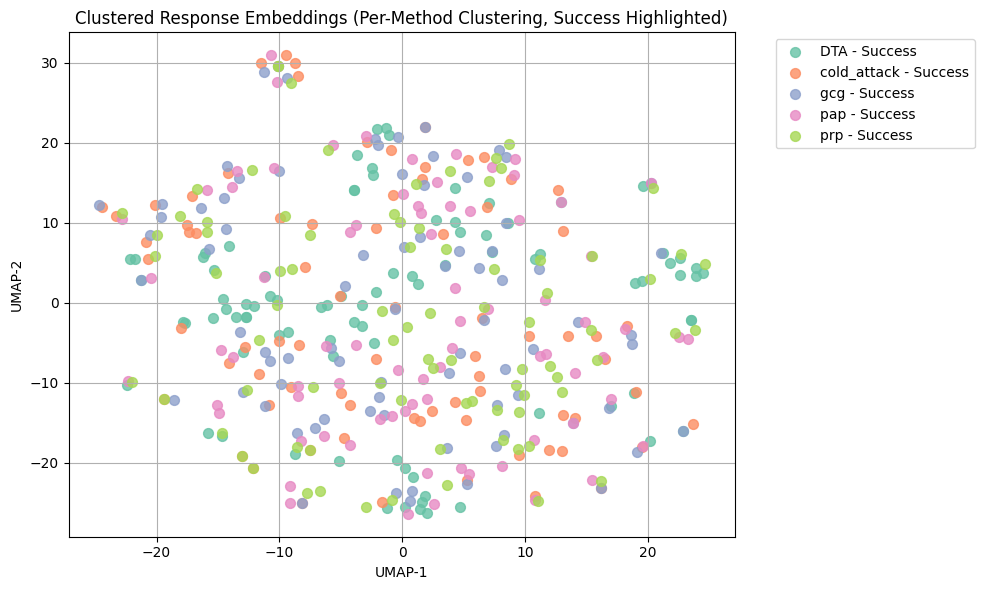

In [50]:
plt.figure(figsize=(10, 6))
palette = sns.color_palette("Set2", n_colors=len(set(all_baseline_labels)))
method_color_map = dict(zip(sorted(set(all_baseline_labels)), palette))

for method in sorted(set(all_baseline_labels)):
    for is_success in ["success", "failure"]:
        subset = df[(df["method"] == method) & (df["success"] == is_success)]
        if len(subset) == 0:
            print("Empty")
            continue  # 跳过空组
        base_color = method_color_map[method]
        if not is_success:
            base_color = tuple(min(1.0, c + 0.3) for c in base_color)
        label = f"{method} - {'Success' if is_success else 'Fail'}"
        plt.scatter(subset["x"], subset["y"], color=base_color, label=label, s=50, alpha=0.8)


# for method in sorted(set(df["method"])):
#     for cid in df[df["method"] == method]["cluster"].unique():
#         group = df[(df["method"] == method) & (df["cluster"] == cid)]
#         if len(group) < 2:
#             continue
#         cov = np.cov(group[["x", "y"]].T)
#         mean = group[["x", "y"]].mean().values
#         λ, v = np.linalg.eig(cov)
#         λ = np.sqrt(λ)
#         angle = np.degrees(np.arctan2(*v[:, 0][::-1]))
#         ellipse = Ellipse(xy=mean, width=λ[0]*4, height=λ[1]*4, angle=angle,
#                           edgecolor=method_color_map[method], fc='None', linestyle='--', lw=1.5, alpha=0.6)
#         plt.gca().add_patch(ellipse)

plt.title("Clustered Response Embeddings (Per-Method Clustering, Success Highlighted)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()